# 01 — Data & EDA: Plant Health Classification

**Dataset:** ziya07/plant-health-monitoring  
**Features:** temperature, air_humidity, soil_moisture  
**Target:** health_status


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import subprocess

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / '../dataset/raw'
MODEL_DIR = BASE_DIR / '../models'

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

csv_path = DATA_DIR / 'plant_health.csv'
print('Packages OK')

Packages OK


In [57]:
if not csv_path.exists():
    try:
        result = subprocess.run(
            ['kaggle','datasets','download','-d','ziya07/plant-health-data','--unzip','-p',str(DATA_DIR)],
            capture_output=True,
            text=True
        )
        print(result.stdout or result.stderr)

        files = list(DATA_DIR.glob('*.csv'))
        if files:
            files[0].rename(csv_path)

    except FileNotFoundError:
        print('Kaggle CLI not installed')

if not csv_path.exists():
    raise FileNotFoundError(f'Missing dataset: {csv_path}')

print('Dataset ready:', csv_path)

Dataset ready: /Users/duongbinh/Documents/M1/Sensor_to_user/Projects/mushroom-aiot-project/ai_analytics/notebooks/../dataset/raw/plant_health.csv


In [58]:
df = pd.read_csv(csv_path)
print(df.shape)
print(df.columns.tolist())
df.head()

(1200, 14)
['Timestamp', 'Plant_ID', 'Soil_Moisture', 'Ambient_Temperature', 'Soil_Temperature', 'Humidity', 'Light_Intensity', 'Soil_pH', 'Nitrogen_Level', 'Phosphorus_Level', 'Potassium_Level', 'Chlorophyll_Content', 'Electrochemical_Signal', 'Plant_Health_Status']


,Timestamp,Plant_ID,Soil_Moisture,Ambient_Temperature,Soil_Temperature,Humidity,Light_Intensity,Soil_pH,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Chlorophyll_Content,Electrochemical_Signal,Plant_Health_Status
0,2024-10-03 10:54:53.407995,1,27.521109,22.240245,21.900435,55.291904,556.172805,5.581955,10.003650,45.806852,39.076199,35.703006,0.941402,High Stress
1,2024-10-03 16:54:53.407995,1,14.835566,21.706763,18.680892,63.949181,596.136721,7.135705,30.712562,25.394393,17.944826,27.993296,0.164899,High Stress
2,2024-10-03 22:54:53.407995,1,17.086362,21.180946,15.392939,67.837956,591.124627,5.656852,29.337002,27.573892,35.706530,43.646308,1.081728,High Stress
3,2024-10-04 04:54:53.407995,1,15.336156,22.593302,22.778394,58.190811,241.412476,5.584523,16.966621,26.180705,26.257746,37.838095,1.186088,High Stress
4,2024-10-04 10:54:53.407995,1,39.822216,28.929001,18.100937,63.772036,444.493830,5.919707,10.944961,37.898907,37.654483,48.265812,1.609805,High Stress


In [59]:
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_', regex=False)

column_mapping = {
    'ambient_temperature': 'temperature',
    'humidity': 'air_humidity',
    'soil_moisture': 'soil_moisture',
    'plant_health_status': 'health_status'
}

df = df.rename(columns=column_mapping)

required_cols = ['temperature', 'air_humidity', 'soil_moisture', 'health_status']
df = df[required_cols].dropna().copy()

df.head()

,temperature,air_humidity,soil_moisture,health_status
0,22.240245,55.291904,27.521109,High Stress
1,21.706763,63.949181,14.835566,High Stress
2,21.180946,67.837956,17.086362,High Stress
3,22.593302,58.190811,15.336156,High Stress
4,28.929001,63.772036,39.822216,High Stress


In [60]:
df = df.dropna()

if 'health_status' not in df.columns:
    raise KeyError(f"health_status column missing. Available columns: {df.columns.tolist()}")

raw_labels = df['health_status'].astype(str).str.lower().str.strip()

label_map = {}

for lbl in raw_labels.unique():
    if 'healthy' in lbl:
        label_map[lbl] = 0
    elif 'warn' in lbl or 'moderate' in lbl:
        label_map[lbl] = 1
    else:
        label_map[lbl] = 2

df['label'] = raw_labels.map(label_map)
CLASS_NAMES = {0: 'healthy', 1: 'warning', 2: 'critical'}

print(label_map)

{'high stress': 2, 'moderate stress': 1, 'healthy': 0}


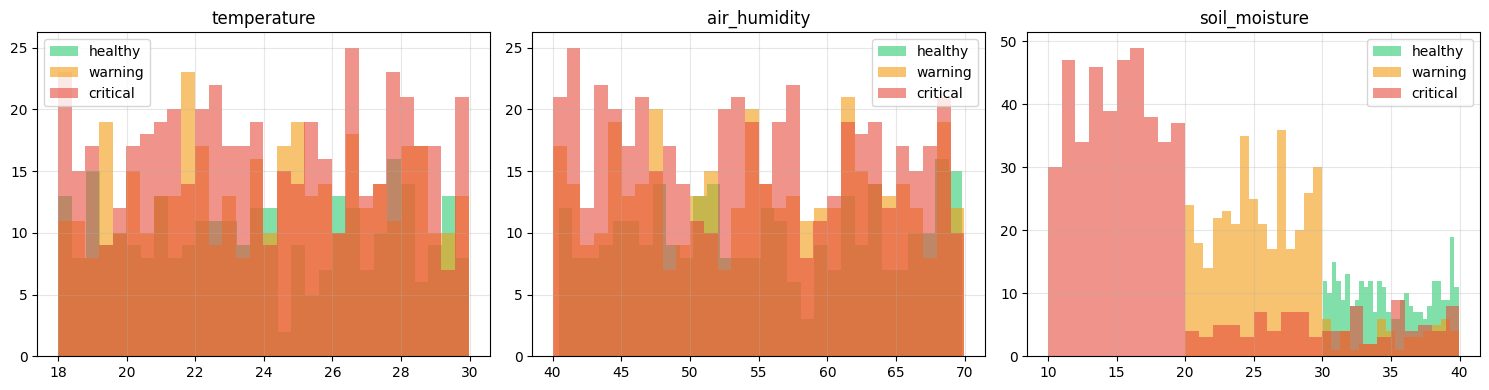

In [61]:
FEATURES = ['temperature','air_humidity','soil_moisture']
palette = {0:'#2ecc71',1:'#f39c12',2:'#e74c3c'}

fig, axes = plt.subplots(1,3,figsize=(15,4))

for ax, feat in zip(axes, FEATURES):
    for lbl, color in palette.items():
        subset = df[df['label']==lbl]
        if not subset.empty:
            subset[feat].hist(ax=ax,bins=30,alpha=0.6,color=color,label=CLASS_NAMES.get(lbl,str(lbl)))

    ax.set_title(feat)
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(MODEL_DIR/'feature_distribution.png')
plt.show()

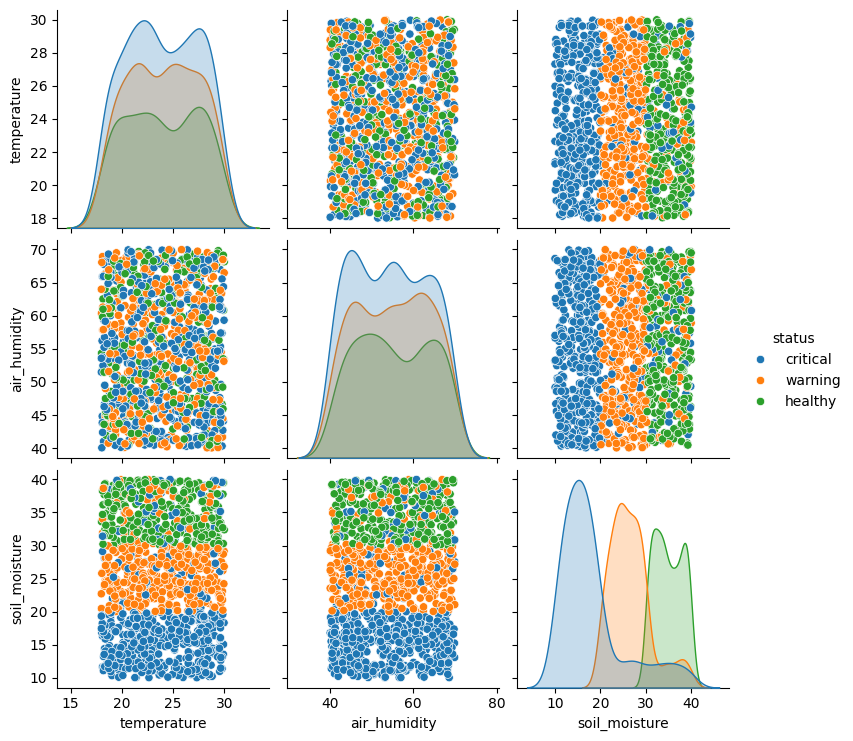

In [62]:
plot_df = df[FEATURES + ['label']].copy()
plot_df['status'] = plot_df['label'].map(CLASS_NAMES)

sns.pairplot(plot_df, hue='status', vars=FEATURES)
plt.savefig(MODEL_DIR/'pairplot.png')
plt.show()

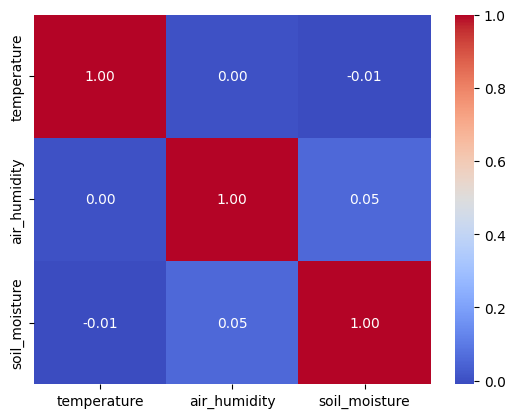

Saved: /Users/duongbinh/Documents/M1/Sensor_to_user/Projects/mushroom-aiot-project/ai_analytics/notebooks/../dataset/raw/plant_health_processed.csv


In [63]:
sns.heatmap(df[FEATURES].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

out = DATA_DIR / 'plant_health_processed.csv'
df[FEATURES + ['label']].to_csv(out, index=False)

print('Saved:', out)